## Find Colocated PACE and EMIT Data
Adapted from the LP.DAAC VITALS ["Finding Concurrent ECOSTRESS and EMIT Data"](https://nasa.github.io/VITALS/python/01_Finding_Concurrent_Data.html) tutorial.

Original Author: Erik Bolch (USGS)

Adapted for PACE by: Skye Caplan (NASA, SSAI), Erik Bolch (USGS)

Last updated: 05/15/2026

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA PACE and EMIT data.

</div>

[edl]: https://urs.earthdata.nasa.gov/

## Summary

NASA's Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) satellite mission and Earth Surface Mineral Dust Source Investigation (EMIT) sensor aboard the International Space Station (ISS) both make hyperspectral observations of the Earth's surface. Taking into account their different spectral, spatial, and temporal coverage, these instruments' complementary capabilities provide a wealth of new opportunities when used in concert. In this series of tutorials, we will demonstrate how to find, prepare, and use data from PACE and EMIT together, illustrating both missions' strengths and how they can help fill in each others' gaps. 

This first tutorial in the series will pull data from EMIT and PACE, specifically PACE's Ocean Color Instrument (OCI), using the `earthaccess` Python library, and demonstrate how to find colocated granules using file metadata. Ultimately, these data will be used in a case study analyzing the 2024-25 wildfires affecting Grampians National Park in Victoria, Australia.

## Background

In order to introduce the synergistic use of these two datasets, we will look at PACE OCI and EMIT observations from the same event, namely wildfires which affected Grampians (Gariwerd) National Park in Victoria, Australia. Two severe fires burned a large portion of the park in a short amount of time - The Yarram Gap Road fire which ignited ~December 16, 2024, and the Wallaby Rocks fire which ignited ~January 29, 2025. These fires started separately but merged into a large complex, burning roughly ~130,000-140,000 ha (State of Victoria, 2025). Before the fires, some areas had not burned in many years, contributing to the fuel load.

The park is home to several endemic flora adapted to the landscape and dry, nutrient poor (low nitrogen, phosphorus, and zinc) soil. Several categories of plant communities exist within the park, including sub-alpine, open forest/scrub, red gum forest, low open shrubland and heathy woodland. For more info about these you can see the [Grampians National Park Flora Guide](https://www.parks.vic.gov.au/-/media/project/pv/main/parks/documents/visitor-guides-and-publications/grampians/grampians-national-park_floraguide.pdf). Fire is common during the dry season and as such, many species are dependent on fire as part of their survival and dispersal (Parks Victoria, nd).

<b>References</b> State of Victoria. 12 September 2025. Fire History Records of Fires across Victoria. Dataset. Retrieved 28 April 2026. https://datashare.maps.vic.gov.au/search?md=d817f3be-a7a2-5847-9944-c0f2fdb39444.

Parks Victoria. Grampians National Park (Gariwerd) Flora Guide. Retrieved 10 April 2026. https://www.parks.vic.gov.au/-/media/project/pv/main/parks/documents/visitor-guides-and-publications/grampians/grampians-national-park_floraguide.pdf

In order to fully explore these fires and their impact on the National Park land, we'll want to use PACE OCI's and EMIT's complementary observation techniques. Referring to the instrument summary below, we can see that OCI has finer temporal repeat, making near-daily, global observations, while EMIT has finer spatial resolution, providing sharp imagery of smaller slices of the Earth. The instruments also have distinct spectral characteristics, which can be used together for full coverage reflectances in the ultraviolet, visible, near infrared, and shortwave infrared regions.

| Resolutions | EMIT    | PACE OCI |
| --------  | --------  | -------- |
| Spatial   | 60 m      | 1.2 km (at nadir)|
| Temporal  | Variable  | 1 - 2 days|
| Spectral Range  | 380 - 2500 nm | 350 - 895, with 7 multispectral SWIR bands from 935-2258 nm|
| Spectral Sampling | 7.5 nm | 2.5 nm, with 1.25 nm in some spectral regions |

## Learning Objectives

At the end of this notebook, you will know how to:
- Search for both PACE and EMIT data using the `earthaccess` package
- Filter those search results to find concurrent datasets based on overpass time, bounding box, etc.
- Download only the datasets which match your filter criteria. 
- Understand the differences in each instruments' orbit characteristics

## Contents
1. [Setup](#1.-Setup)
2. [Searching for Data](#2.-Searching-for-Data)
3. [Filtering Data](#3.-Filtering-Data)
4. [Making the most of PACE's temporal coverage](#4.-Making-the-most-of-PACE's-temporal-coverage)
5. [Downloading Data](#5.-Downloading-Data)


## 1. Setup

Begin by importing all of the packages used in this notebook.

In [1]:
import folium
import earthaccess
import numpy as np 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from skimage import io
from shapely import geometry
from datetime import timedelta
from branca.element import Figure
from IPython.display import display
from shapely.geometry import Polygon, box

import warnings
warnings.filterwarnings('ignore')

## 2. Searching for Data

One of the easiest ways to retrieve NASA data is through the `earthaccess` package, which allows us to search quickly through the multitude of  datasets available on [NASA's Earthdata Cloud](https://earthdata.nasa.gov) for the the ones which match our criteria. Please make sure you have the most updated version of the package (`earthaccess=>0.17.0`), as some of the functions in this notebook rely on newer utilities. In this tutorial, we'll be looking for observations of Grampians National Park from our two instruments of interest before and after the wildfires, to understand how each mission views the change in landscape. 

The following cell will allow you to log in to NASA's Earthdata Cloud catalogue just as you would through a browser with the `earthaccess.login()` method. Note that you can add `persist=True` as an argument to `earthaccess.login()` to save your credentials in a `.netrc` file, so you won't need to login using your Earthdata credentials each time you use this notebook. 

In [2]:
auth = earthaccess.login()

Now that we're logged in, we can define parameters to begin our search for data using a specific timespan, a region of interest (ROI), and the products we are looking for.

From the background section above, we know the location and time period over which these fires burned. We also know that EMIT will be the temporal limiting factor for the analyses in the next few notebooks due to its variable revisit time. Thankfully, our interest in the pre- and post-fire conditions of the park will allow us to use data from a month or two before and after the fires if necessary. We'll also be searching for surface reflectances from each mission to investigate the fires, looking for our pre-fire granules first, and the post-fire data after. 

The Yarram Gap Road fire began around December 16th, 2024, so we will set our search about a month out from that date. We will also need to know the `short_names` of the products we want to search for, essentially the names of the datasets in the Earthdata catalogue. 

In [3]:
tspan = ('2024-11-01','2024-12-16')
roi_bounds = (141.9385, -37.74163, 142.77324, -36.79961)

bbox = geometry.box(*roi_bounds, ccw=True)
roi = list(bbox.exterior.coords)
gdf = gpd.GeoDataFrame(index=[0], crs='epsg:4326', geometry=[bbox])

prods = ["PACE_OCI_L2_SFREFL", "EMITL2ARFL"]

With the parameters set, we can use `earthaccess.search_data()` to look through our chosen collections.

In [4]:
results = earthaccess.search_data(
    short_name=prods,
    polygon=roi,
    temporal=tspan,
)

len(results)

71

Running the search gathered ~70 granules that match the parameters. That is a lot of data! Let's examine what the first two results from the `earthaccess` call look like. Running the cell below, we have 2 EMIT granules with all their associated metadata that matched the criteria in our query above. If you were to look through the whole `results` list, you'd see the same for however many PACE OCI granules fit the search parameters as well. These metadata will allow us to sort through all of the results to choose the best granules for our analyses.

In [5]:
results[:2]

[Collection: {'ShortName': 'EMITL2ARFL', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 141.6588134765625, 'Latitude': -37.22526168823242}, {'Longitude': 140.77365112304688, 'Latitude': -37.822025299072266}, {'Longitude': 141.2333984375, 'Latitude': -38.50394058227539}, {'Longitude': 142.11856079101562, 'Latitude': -37.90717697143555}, {'Longitude': 141.6588134765625, 'Latitude': -37.22526168823242}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-11-14T03:57:35Z', 'EndingDateTime': '2024-11-14T03:57:47Z'}}
 Size(MB): 3577.064754486084
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035735_2431902_007/EMIT_L2A_RFL_001_20241114T035735_2431902_007.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035735_2431902_007/EMIT_L2A_RFLUNCERT_001_20241114T035735_243190

## 3. Filtering Data

In order to use the metadata efficiently, and to make it more human-readable, we can make our list of results into a `GeoDataFrame` by taking the spatial metadata and creating a shapely polygon representing the spatial coverage, and further customize which information we want to use from other metadata fields. These methods are explained more thoroughly in the VITALS ECOSTRESS-EMIT tutorial [`01_Finding_Concurrent_Data`](https://nasa.github.io/VITALS/python/01_Finding_Concurrent_Data.html). 

In [6]:
# Functions to Build Dataframe
def get_shapely_object(result: earthaccess.results.DataGranule):
    """
    Create a shapely polygon of spatial coverage from results metadata.
    Will work for BoundingRectangles or GPolygons.
    """
    # Get Geometry Keys
    geo = result["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]
    keys = geo.keys()

    if "BoundingRectangles" in keys:
        bounding_rectangle = geo["BoundingRectangles"][0]
        # Create bbox tuple
        bbox_coords = (
            bounding_rectangle["WestBoundingCoordinate"],
            bounding_rectangle["SouthBoundingCoordinate"],
            bounding_rectangle["EastBoundingCoordinate"],
            bounding_rectangle["NorthBoundingCoordinate"],
        )
        # Create shapely geometry from bbox
        shape = box(*bbox_coords, ccw=True)
    elif "GPolygons" in keys:
        points = geo["GPolygons"][0]["Boundary"]["Points"]
        # Create shapely geometry from polygons
        shape = Polygon([[p["Longitude"], p["Latitude"]] for p in points])
    else:
        raise ValueError(
            "Provided result does not contain bounding boxes/polygons or is incompatible."
        )
    return shape

# Functions to Build Dataframe
def get_png(result: earthaccess.results.DataGranule):
    """
    Retrieve a png browse image if it exists or first jpg in list of urls
    """
    https_links = [link for link in result.dataviz_links() if "https" in link]
    if len(https_links) == 1:
        browse = https_links[0]
    elif len(https_links) == 0:
        browse = "no browse image"
    else:
        browse = [png for png in https_links if ".png" in png][0]
    if browse == 'no browse image':
        print("Some granules have no browse imagery.")
    return browse

def results_to_gdf(results: list, keep_cols: list = None, roi:gpd.GeoDataFrame=None):
    """
    Takes a list of results from earthaccess and converts to a geodataframe.
    """
    # Create Dataframe of Results Metadata
    results_df = pd.json_normalize(results)
    # Shorten column Names
    results_df.columns = [
        col.split(".")[-1] if "." in col else col for col in results_df.columns
    ]
    # Create shapely polygons for result
    geoms = gpd.GeoSeries(results, crs=4326)
    # Convert to GeoDataframe
    gdf = gpd.GeoDataFrame(results_df, geometry=geoms, crs="EPSG:4326")
    # Add browse imagery and data links and product shortname
    gdf["browse"] = [get_png(granule) for granule in results]
    gdf["shortname"] = [
        result["umm"]["CollectionReference"]["ShortName"] for result in results
    ]
    gdf["data"] = [granule.data_links() for granule in results]
    
    # Drop Unwanted Columns
    default_cols = [
    "native-id",
    "collection-concept-id",
    "BeginningDateTime",
    "EndingDateTime",
    "CloudCover",
    "DayNightFlag",
    "geometry",
    "browse",
    "shortname",
    "data",
    ]   

    if not keep_cols:
        keep_cols = default_cols
    else:
        keep_cols = list(set(keep_cols + default_cols))

    gdf = gdf[[col for col in keep_cols if col in gdf.columns]]

    # Convert Timestamps
    gdf['BeginningDateTime'] = pd.to_datetime(gdf['BeginningDateTime'])
    gdf['EndingDateTime'] = pd.to_datetime(gdf['EndingDateTime'])
    gdf['datetime_obj'] = pd.to_datetime(gdf['BeginningDateTime'], format='ISO8601')

    
    if roi is not None:
        gdf_eq = gdf.to_crs("EPSG:8857")
        roi_eq = roi.to_crs("EPSG:8857").union_all()
                
        gdf['overlap_frac'] = gdf_eq.geometry.intersection(roi_eq).area / gdf_eq.geometry.area
    
    return gdf

We can place our results in a geodataframe and look at the first few lines with the cell below. Each granule has various "IDs" related to the file or collection name, the host Distributed Active Archive Center (DAAC), and more. There are also other columns related to the boundaries, time of data collection, and more - not all of this information will be useful to us in finding collocated PACE and EMIT observations.

In [7]:
gdf = results_to_gdf(results)

gdf.head()

,native-id,collection-concept-id,BeginningDateTime,EndingDateTime,CloudCover,DayNightFlag,geometry,browse,shortname,data,datetime_obj
0,EMIT_L2A_RFL_001_20241114T035735_2431902_007,C2408750690-LPCLOUD,2024-11-14 03:57:35+00:00,2024-11-14 03:57:47+00:00,96.0,Day,"MULTIPOLYGON (((141.65881 -37.22526, 140.77365...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...,2024-11-14 03:57:35+00:00
1,EMIT_L2A_RFL_001_20241114T035747_2431902_008,C2408750690-LPCLOUD,2024-11-14 03:57:47+00:00,2024-11-14 03:57:59+00:00,18.0,Day,"MULTIPOLYGON (((142.35135 -36.7495, 141.48019 ...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...,2024-11-14 03:57:47+00:00
2,EMIT_L2A_RFL_001_20241114T035759_2431902_009,C2408750690-LPCLOUD,2024-11-14 03:57:59+00:00,2024-11-14 03:58:11+00:00,1.0,Day,"MULTIPOLYGON (((143.03061 -36.26859, 142.17642...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...,2024-11-14 03:57:59+00:00
3,EMIT_L2A_RFL_001_20241118T022139_2432301_006,C2408750690-LPCLOUD,2024-11-18 02:21:39+00:00,2024-11-18 02:21:51+00:00,100.0,Day,"MULTIPOLYGON (((142.77542 -36.84862, 141.90176...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...,2024-11-18 02:21:39+00:00
4,EMIT_L2A_RFL_001_20241118T022151_2432301_007,C2408750690-LPCLOUD,2024-11-18 02:21:51+00:00,2024-11-18 02:22:03+00:00,99.0,Day,"MULTIPOLYGON (((143.46039 -36.36956, 142.60107...",https://data.lpdaac.earthdatacloud.nasa.gov/lp...,EMITL2ARFL,[https://data.lpdaac.earthdatacloud.nasa.gov/l...,2024-11-18 02:21:51+00:00


To view how many individual overpasses exist for the ROI from each instrument in time, we'll now create separate dataframes for PACE OCI and EMIT. This will also allow us to compare the time of overpass for each granule on the same day. 

In [8]:
pace_gdf = gdf[gdf['native-id'].str.contains('OCI')]
emit_gdf = gdf[gdf['native-id'].str.contains('EMIT')]
print(f' PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

 PACE OCI Granules: 64 
 EMIT Granules: 7


Clearly, most of our results were PACE granules - that makes sense given the orbit characteristics laid out in the background section of this tutorial. We want to find which of these many overpasses overlap spatially with the EMIT observations, so we'll subset PACE granules in `pace_gdf` by whether they intersect with EMIT granules. We'll create a new column based on intersection with the union of EMIT polygons.

In [9]:
pace_gdf['intersects'] = pace_gdf.intersects(emit_gdf.union_all())

# Subset by intersection
pace_gdf = pace_gdf[pace_gdf['intersects'] == True]
print(f' PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

 PACE OCI Granules: 63 
 EMIT Granules: 7


After checking for spatial overlap, we still have a ton of PACE data to work with, thankfully. 

The next step is to make sure the measurements from both instruments are comparable in time to minimize any variation in cloud cover, solar angle, etc. PACE has a local overpass time of ~1:00 pm, whereas EMIT's overpasses are more variable, so we'll use a threshold of +-6 hours to match the datasets.

In [10]:
def concurrent_match(gdf_a:pd.DataFrame, gdf_b:pd.DataFrame, col_name:str, time_delta:timedelta):
    """
    Cross references dataframes containing a datetime object column and keeps rows in 
    each that fall within the provided timedelta of the other. Acceptable time_delta examples:
    
    months=1
    days=1
    hours=1
    minutes=1
    seconds=1
    """
    # Match Timestamps from Dataframe A with Time-range of entries in Dataframe B
    # Create empty list
    a_list = []
    # Iterate results for product a based on index values
    for _n in gdf_b.index.to_list():
        # Find where product b is within the window of each product a result
        a_matches = (gdf_a[col_name] > gdf_b[col_name][_n]-time_delta) & (gdf_a[col_name] < gdf_b[col_name][_n]+time_delta)
        # Append list with values
        a_list.append(a_matches)
    # Match Timestamps from Dataframe B with Time-range of entries in Dataframe A
    # Create empty list
    b_list =[]
    for _m in gdf_a.index.to_list():
        # Find where product a is within the window of each product b result
        b_matches = (gdf_b[col_name] > gdf_a[col_name][_m]-time_delta) &  (gdf_b[col_name] < gdf_a[col_name][_m]+time_delta)
        # Append list with values
        b_list.append(b_matches)
    # Filter Original Dataframes by summing list of bools, 0 = outside of all time-ranges
    a_filtered = gdf_a.loc[sum(a_list) > 0]
    b_filtered = gdf_b.loc[sum(b_list) > 0]
    return(a_filtered, b_filtered)

pace_gdf, emit_gdf = concurrent_match(pace_gdf,emit_gdf, col_name='datetime_obj',time_delta=timedelta(hours=6))
print(f'After concurrent match:\n PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

After concurrent match:
 PACE OCI Granules: 4 
 EMIT Granules: 7


The number of PACE granules has drastically decreased, which means that the list of PACE granules should only contain those within 6 hours of one of our 7 EMIT granules. Recall that PACE collects data approximately once a day, while EMIT could have several scenes in the same day, which is why the number of granules does not match. 

The final step in choosing the best data day our purposes is to make sure the ROI is clear of clouds or bad data. We can do this by using browse images, basically previews, of each granule. These browse images are simple RGB representations of the data which will give an idea of what the overpass looks like before we decide to download it. 

Let's plot the browse imagery for both PACE and EMIT below:

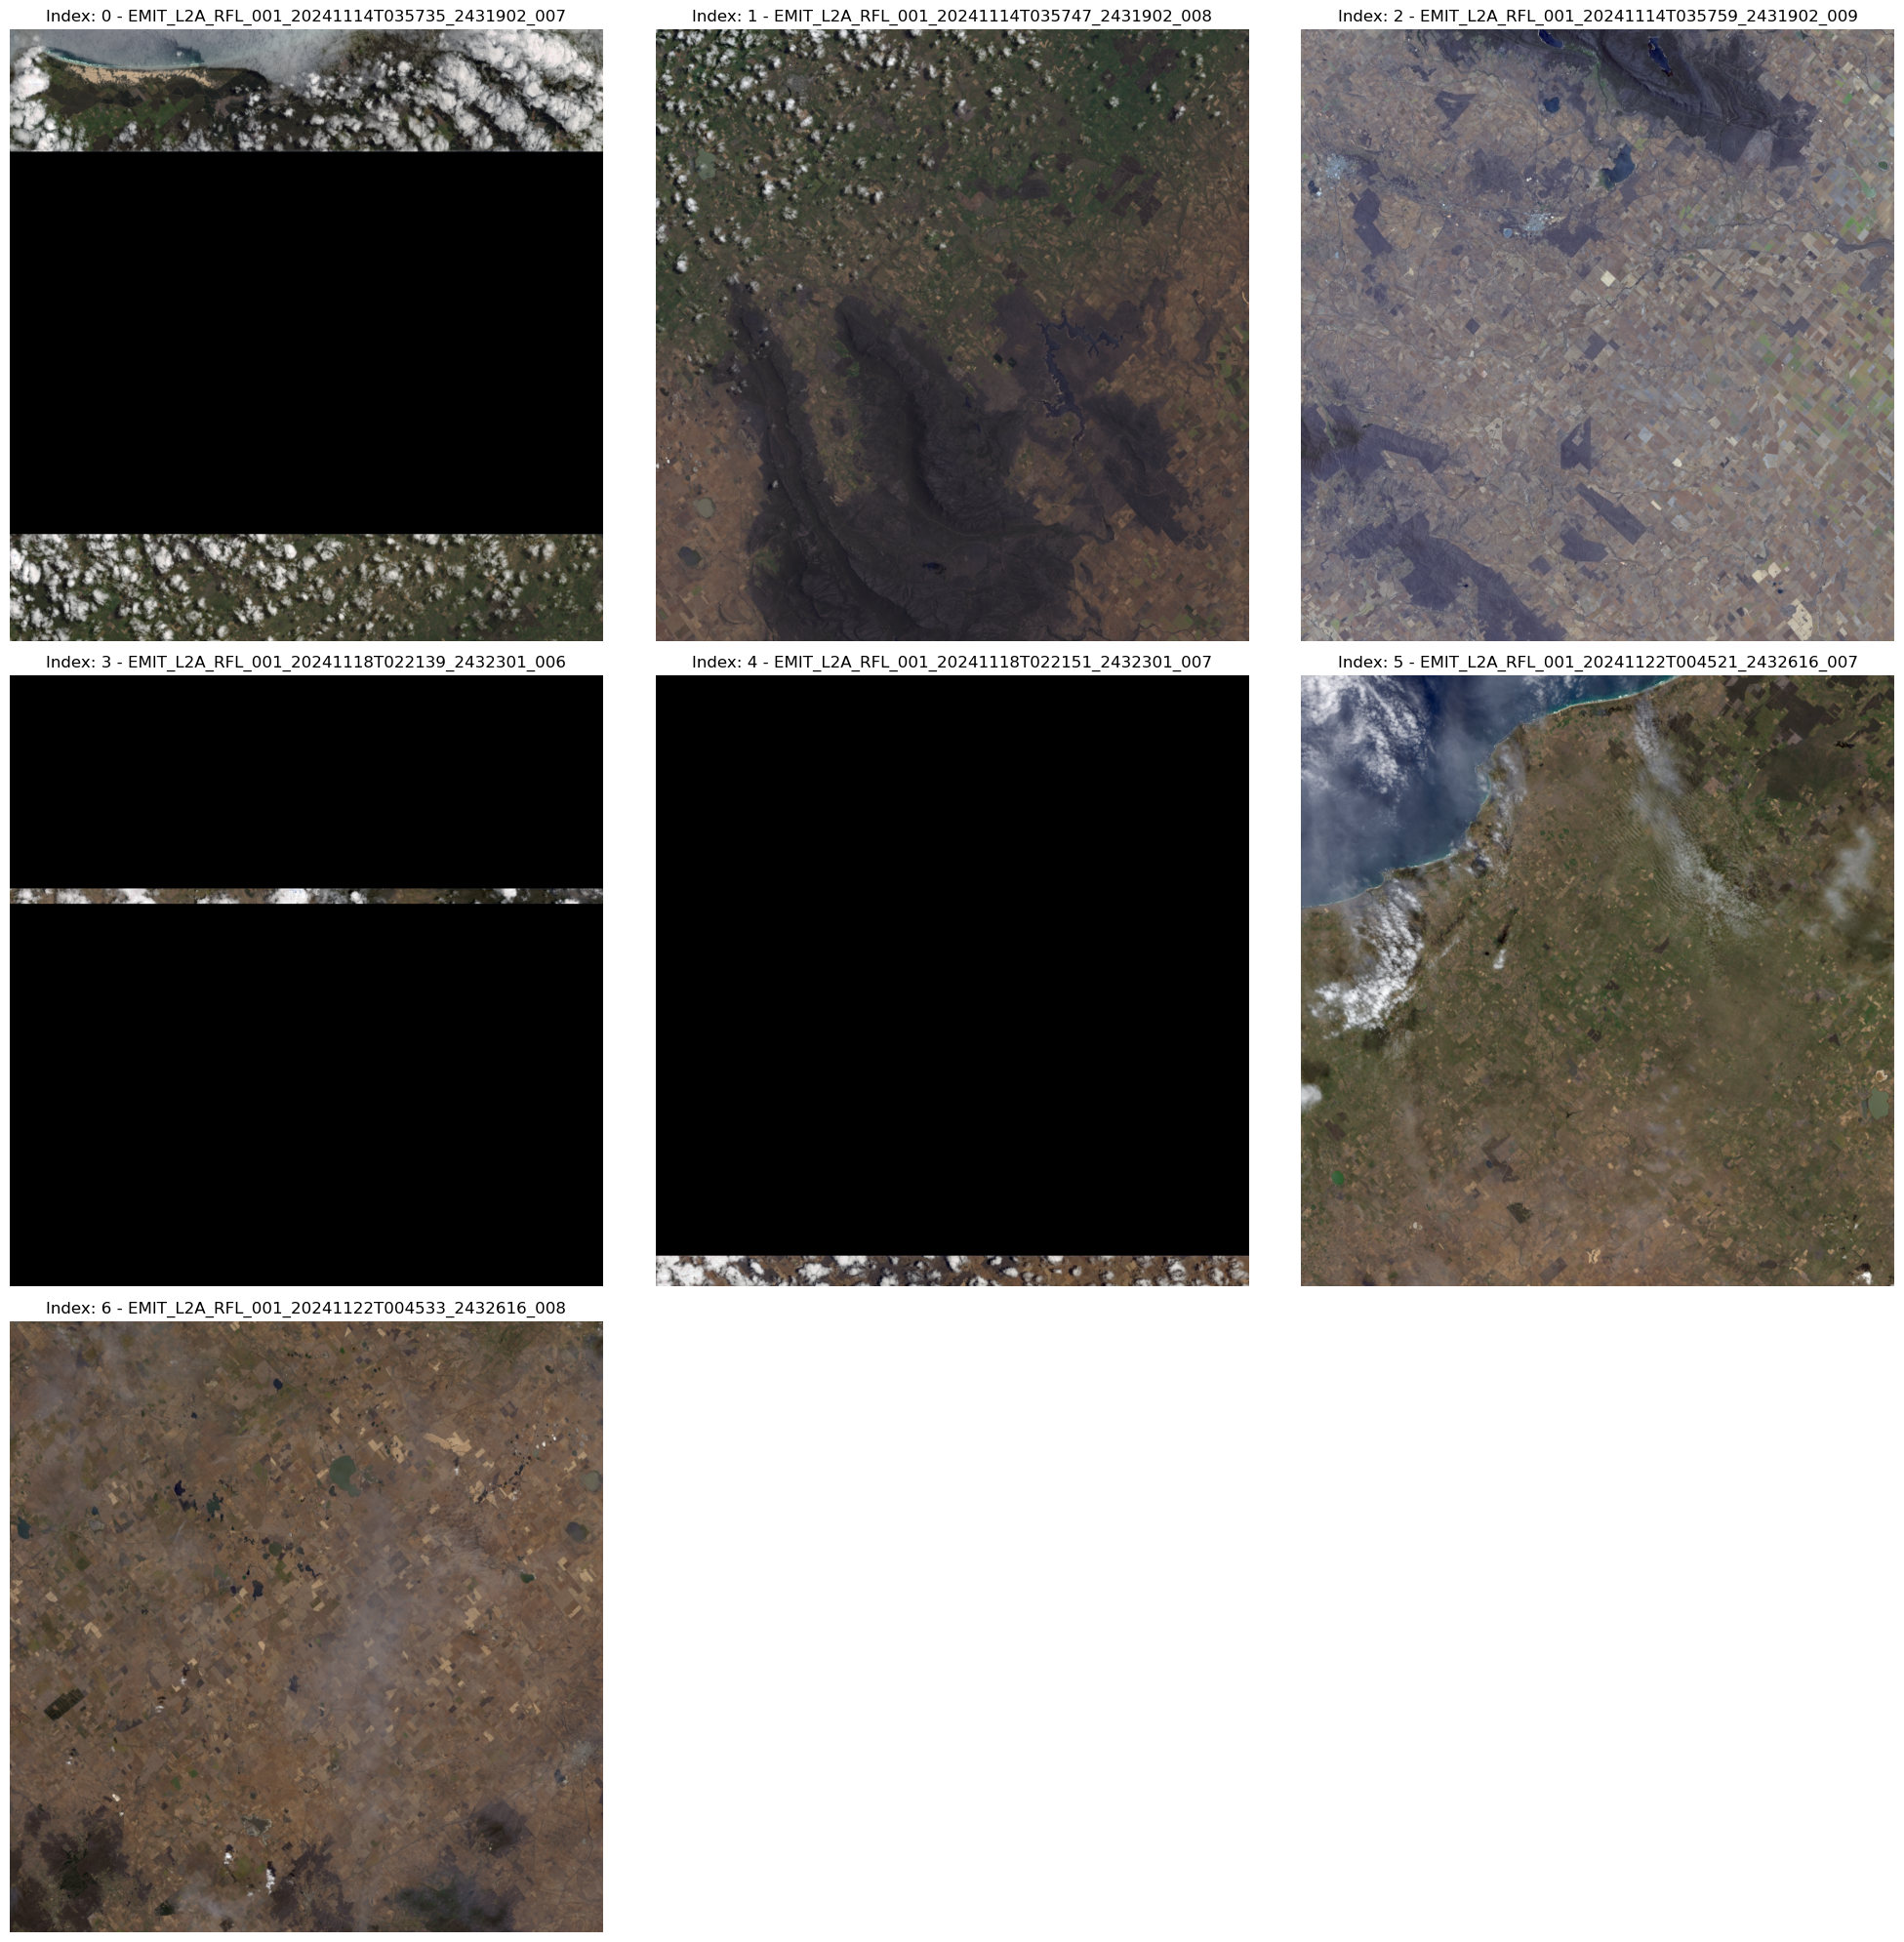

In [11]:
def plot_browse_images(gdf, cols=3):
    """
    Plot browse images using a given GeoDataFrame with the applicable metadata.
    Args:
        gdf - GeoDataFrame including the "browse" metadata from earthaccess
        cols - the number of columns in the desired plot
    
    Returns:
        A plot of browse images
    """
    rows = int(np.ceil(len(gdf)/cols))
    fig, ax = plt.subplots(rows, cols, figsize=(20,20))
    ax = ax.flatten()

    for _n, index in enumerate(gdf.index.to_list()):
        img = io.imread(gdf['browse'][index])
        ax[_n].imshow(img)
        ax[_n].set_title(f"Index: {index} - {gdf['native-id'][index]}")
        ax[_n].axis('off')

    for i in range(len(gdf), len(ax)): 
        fig.delaxes(ax[i]) 

    plt.tight_layout() 
    plt.show() 

plot_browse_images(emit_gdf)

The EMIT granules at index 1 and 2 are taken on the same day and show Grampians National Park most clearly, with no clouds or bad data covering the ROI. Hopefully, the PACE data matches 

At time of writing, PACE browse imagery is still being implemented. Once the implementation is complete, we'll be able to make the same plot with PACE. For this exercise, we'll assume our ROI in each OCI granule is free of clouds and isn't affected by any quality issues, which can be verified by this screenshot from [NASA Worldview](https://worldview.earthdata.nasa.gov/?v=130.20350769629988,-44.84201943466406,151.83477033495035,-32.73702465944704&l=Reference_Labels_15m(hidden),Reference_Features_15m(hidden),Coastlines_15m,OCI_PACE_True_Color,VIIRS_NOAA21_CorrectedReflectance_TrueColor(hidden),VIIRS_NOAA20_CorrectedReflectance_TrueColor(hidden),VIIRS_SNPP_CorrectedReflectance_TrueColor(hidden),MODIS_Aqua_CorrectedReflectance_TrueColor(hidden),MODIS_Terra_CorrectedReflectance_TrueColor(hidden)&lg=true&t=2024-11-14-T18%3A46%3A01Z) for this scene:

![An image of the PACE granule which overlaps with the EMIT granule chosen above. Although there are clouds present in the image, they do not affect the area over or around Grampians National Park, the ROI for this analysis](data/worldview_20241114T035224_browse.png)

In [ ]:
# Plot PACE browse images - coming soon!
#plot_browse_images(pace_gdf)

Before we get too excited about using those two granules, the last thing we need to make sure of is that our EMIT granule, and thus our ROI, is in a decent position relative to the entire OCI swath. Its relative location is important because Level 2 (L2) reflectances are in the swath resolution, and OCI's swath is ~2700 km. Because of its very wide swath, pixels toward the east and west edges of a L2 OCI granule tend to include greater angular effects. To minimize those effects, it is preferable to choose EMIT and PACE pairs where the ROI is closer to the center of OCI's swath. 

The browse images are great quick looks, but they do not demonstrate well just how broad OCI's swath is, or where the ROI falls within OCI's swath. Instead, we'll make a quick interactive plot with `folium`:

In [12]:
# Create Figure and Select Background Tiles
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

# Plot PACE OCI Results - note we must drop the datetime_obj columns for this to work
pace_gdf.drop(columns=['datetime_obj']).explore(
    "native-id",
    categorical=True,
    tooltip=[
        "native-id",
        "BeginningDateTime",
        "CloudCover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="PACE OCI",
    m=map1,
    legend=False
)

# Plot EMIT Results - note we must drop the datetime_obj columns for this to work
emit_gdf.drop(columns=['datetime_obj']).explore(
    "native-id",
    categorical=True,
    tooltip=[
        "native-id",
        "BeginningDateTime",
        "CloudCover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="EMIT",
    m=map1,
    legend=False
)

folium.GeoJson(bbox,
                name='bounding_box',
                ).add_to(map1)

x1, y1, x2, y2 = gdf.union_all().bounds
map1.fit_bounds(bounds=((y1, x1), (y2, x2)))
map1.add_child(folium.LayerControl())
display(fig)

The `folium` map above illustrates well just how different the area these instruments are observating can be. It also shows clearly where in OCI granule each respective EMIT granule falls - we can see that for the observations on November 14th, 2024, the EMIT granules fall closer to the center of the PACE OCI granule and cover the whole expanse of the park. Conversely, most of the other EMIT granules fall to the edges of their paired OCI granules. 

With these quick checks, we can be confident that the data from November 14th, 2024 is the right pre-fire data to use. Now we can grab those granules from their respective GeoDataFrames and put them in a single list for easy download later. Note that we will be grabbing two EMIT granules to cover the full footprint of Grampians National Park.

In [15]:
# Filter PACE using date of observation, since there is only one per day here
good_pace_gran = pace_gdf[pace_gdf['native-id'].str.contains("20241114")]

# Filter EMIT using index from the browse imagery plot
good_idxs = [1,2] 
good_emit_grans = emit_gdf[emit_gdf.index.isin(good_idxs)]
keep_granules = good_pace_gran.index.to_list()+good_emit_grans.index.to_list()
keep_granules.sort()

prefire_results = [result for i, result in enumerate(results) if i in keep_granules]
prefire_results

[Collection: {'ShortName': 'EMITL2ARFL', 'Version': '001'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': 142.35134887695312, 'Latitude': -36.74950408935547}, {'Longitude': 141.48019409179688, 'Latitude': -37.349632263183594}, {'Longitude': 141.94595336914062, 'Latitude': -38.025718688964844}, {'Longitude': 142.81710815429688, 'Latitude': -37.42559051513672}, {'Longitude': 142.35134887695312, 'Latitude': -36.74950408935547}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-11-14T03:57:47Z', 'EndingDateTime': '2024-11-14T03:57:59Z'}}
 Size(MB): 3579.740264892578
 Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFLUNCERT_001_20241114T035747

### Search and filter for post-fire data

We have our pre-fire results, and so can now repeat the process above to find post-fire data. We will combine several of the steps completed above to search and filter the data, especially because the only real change to make is in the time span we include in the `earthaccess.search_data()` call. The fires were controlled around mid-February 2025, so we will set our time span to ~1-2 months after that date.

In [13]:
tspan = ('2025-02-28','2025-03-30')

results = earthaccess.search_data(
    short_name=prods,
    polygon=roi,
    temporal=tspan,
)

gdf = results_to_gdf(results)

print(f'{gdf.shape[0]} granules total')

pace_gdf = gdf[gdf['native-id'].str.contains('OCI')]
emit_gdf = gdf[gdf['native-id'].str.contains('EMIT')]
print(f' PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

pace_gdf['intersects'] = pace_gdf.intersects(emit_gdf.union_all())

pace_gdf = pace_gdf[pace_gdf['intersects'] == True]
pace_gdf, emit_gdf = concurrent_match(pace_gdf,emit_gdf, col_name='datetime_obj',time_delta=timedelta(hours=6))
print(f'After concurrent match:\n PACE OCI Granules: {pace_gdf.shape[0]} \n EMIT Granules: {emit_gdf.shape[0]}')

51 granules total
 PACE OCI Granules: 46 
 EMIT Granules: 5
After concurrent match:
 PACE OCI Granules: 2 
 EMIT Granules: 5


We have an even smaller number of colocated granules now, so let's again visualize the EMIT and PACE data.

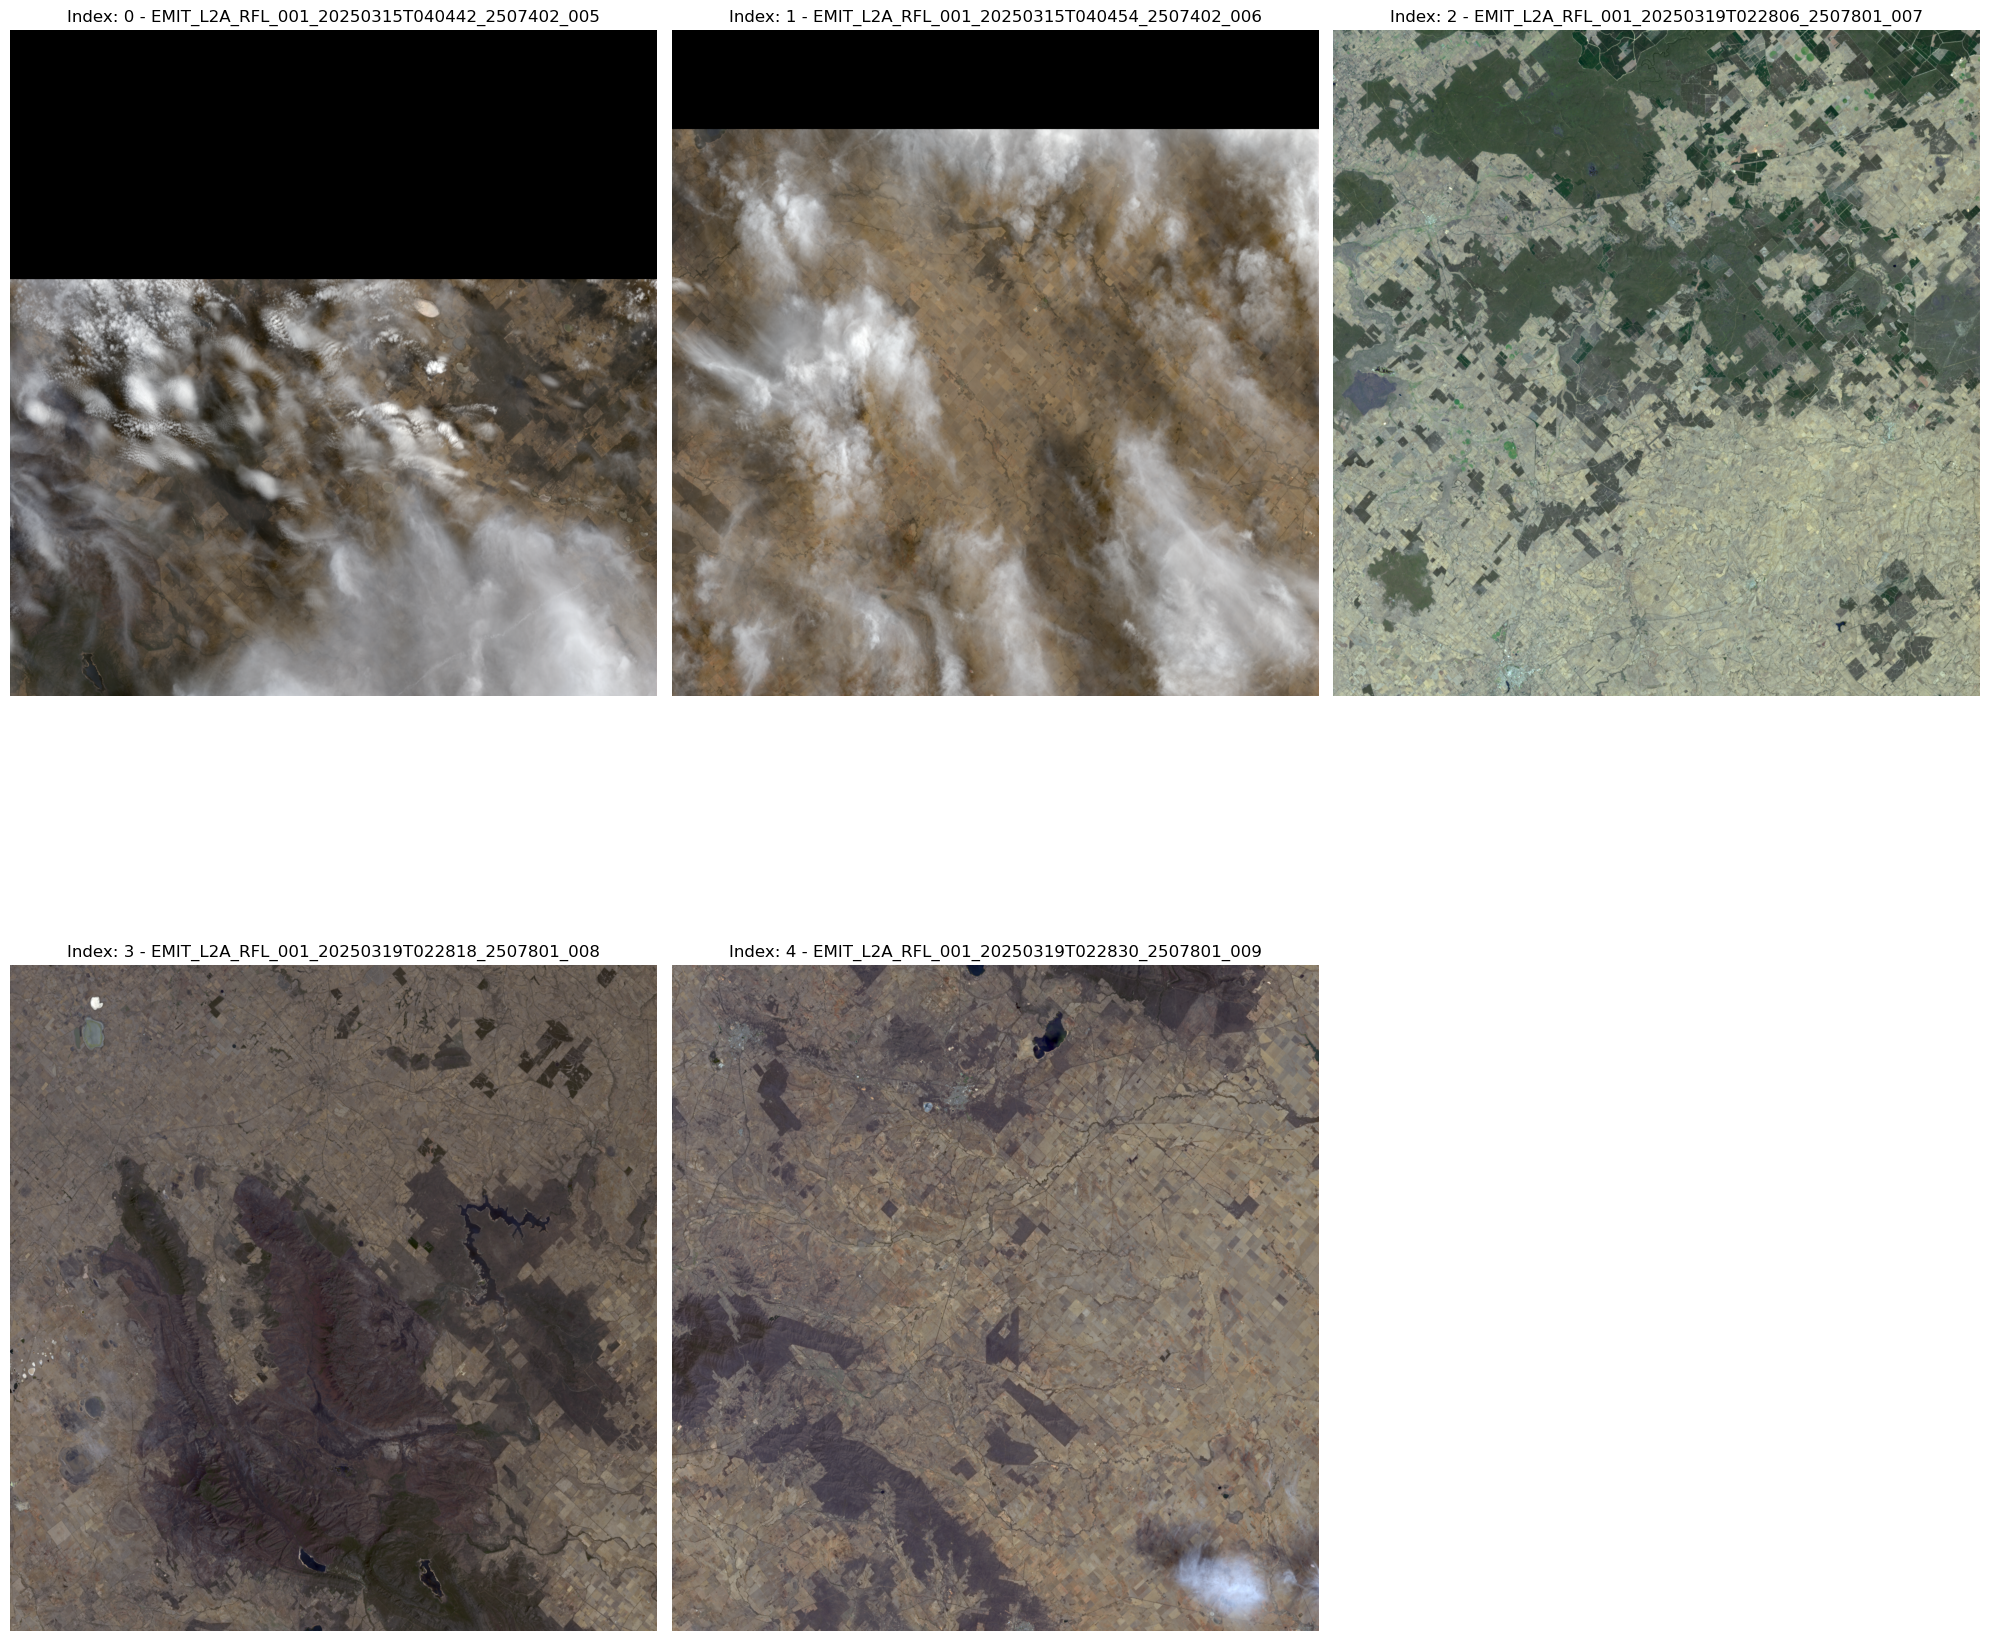

In [14]:
plot_browse_images(emit_gdf)

# PACE browse images coming soon!
#plot_browse_images(pace_gdf)

The EMIT data from March 19th, 2025 looks clearest, so let's create another `folium` map to visualize the PACE and EMIT overlaps.

In [18]:
fig = Figure(width="750px", height="375px")
map1 = folium.Map(tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}', attr='Google')
fig.add_child(map1)

pace_gdf.drop(columns=['datetime_obj']).explore(
    "native-id",
    categorical=True,
    tooltip=[
        "native-id",
        "BeginningDateTime",
        "CloudCover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="PACE OCI",
    m=map1,
    legend=False
)

emit_gdf.drop(columns=['datetime_obj']).explore(
    "native-id",
    categorical=True,
    tooltip=[
        "native-id",
        "BeginningDateTime",
        "CloudCover",
    ],
    popup=True,
    style_kwds=dict(fillOpacity=0.1, width=2),
    name="EMIT",
    m=map1,
    legend=False
)

folium.GeoJson(bbox,
                name='bounding_box',
                ).add_to(map1)

x1, y1, x2, y2 = gdf.union_all().bounds
map1.fit_bounds(bounds=((y1, x1), (y2, x2)))
map1.add_child(folium.LayerControl())
display(fig)

The EMIT granules from 03/19/2025 are still in a perfectly acceptable position relative to the OCI swath, so again we'll extract those granules from their respective `gdf`s and combine the two lists into a final granule list. Note that we'll need two EMIT granules to cover the park footprint this time, as well. 

In [19]:
good_pace_gran = pace_gdf[pace_gdf['native-id'].str.contains("20250319")]

good_idxs = [3,4]
good_emit_grans = emit_gdf[emit_gdf.index.isin(good_idxs)]
keep_granules = good_pace_gran.index.to_list()+good_emit_grans.index.to_list()
keep_granules.sort()

postfire_results = [result for i, result in enumerate(results) if i in keep_granules]

# Combine pre- and post-fire results into one list
granules = prefire_results+postfire_results

## 4. Making the most of PACE's temporal coverage

You'll notice that the dates we chose for our pre- and post-fire imagery, 11/14/2024 and 03/19/2025, have a span of several months between them that we are not currently capturing in our analysis. Although EMIT's temporal revisit is a limiting factor, PACE does see this area every day and can thus show us how the fires evolved over the days between our before and after imagery, adding some temporal context to EMIT's sharp spatial context.

In [20]:
results = earthaccess.search_data(
    short_name=["PACE_OCI_L2_SFREFL"],
    polygon=roi,
    temporal=('2024-11-15','2025-03-18'),
)

print(f"Number of PACE OCI granules: {len(results)}")

Number of PACE OCI granules: 172


Remember that PACE overpasses occur once, and sometimes twice, a day in this region, giving a total of 172 results. That's a lot of data, much of which we know will be covered in clouds. We could include the `cloud_cover` search parameter in the `earthaccess.search_data()` call, but PACE's swath is very wide, and it is entirely possible that a granule with high cloud cover overall would be clear over our ROI. Some days may also have our ROI covered in smoke, since we know we're looking at fires in this tutorial series. 

The same browse imagery process as above would help visually sort through these granules, but for this volume of data, sometimes it can be useful (and more computer memory-friendly) to use tools like Worldview for quick searches. Worldview allows you create gifs of sequences of data, like the one at [this link](https://worldview.earthdata.nasa.gov/?v=135.69330009227843,-41.034094576269695,148.3782505015899,-33.93551410994782&as=2024-11-15-T00%3A00%3A00Z&ae=2025-03-19-T00%3A00%3A00Z&l=Reference_Labels_15m(hidden),Reference_Features_15m(hidden),Coastlines_15m,OCI_PACE_True_Color,VIIRS_NOAA21_CorrectedReflectance_TrueColor(hidden),VIIRS_NOAA20_CorrectedReflectance_TrueColor(hidden),VIIRS_SNPP_CorrectedReflectance_TrueColor(hidden),MODIS_Aqua_CorrectedReflectance_TrueColor(hidden),MODIS_Terra_CorrectedReflectance_TrueColor(hidden)&lg=true&av=1.5&ab=on&t=2025-03-19-T00%3A00%3A00Z) which we have used to isolate several good data days for PACE OCI imagery between 11/14/2024 and 03/19/2025. 

We can download these time series images to use in conjunction with our pre- and post-fire data from the cells above.

In [21]:
pace_ts_gdf = results_to_gdf(results)

timestamps = ["20250101T033916", "20250118T033938", "20250122T041511", 
              "20250205T040925", "20250211T042542", "20250212T032254",
              "20250224T035613", "20250301T033714", "20250304T034526",
              "20250305T042058", "20250307T035339", "20250313T041003",]

pace_ts_idxs = [pace_ts_gdf[pace_ts_gdf['native-id'].str.contains(i)].index.to_list()[0] for i in timestamps]
ts_results = [result for i, result in enumerate(results) if i in pace_ts_idxs]

## 5. Downloading data

<div class="alert alert-info" role="alert">

Note that the total size of the following downloads are 7.7 GB and 8.5 GB, respectively. If there is too much data here to download for you, the subsets to our ROI are available in the repo.

</div>

### Pre- and post-fire granules

As a final step, we'll use the lists we just created to download (or stream if you are running this on a cloud-based compute platform) the data we want. 

If we inspected the EMIT elements in the `granules` list, we would see that the `Data` key is a list of three links, not just one as in the PACE datasets. Three links mean there are three datasets, which exist because the `EMITL2ARFL` collection contains separate files for the reflectances, uncertainties, and mask information. The next two tutorials in this series only require the reflectances and quality masks, so we will filter out the uncertainty files from the final download list. 

In [22]:
urls = []
for i in range(len(granules)):
    links = [l for l in granules[i].data_links(access="external") if "UNCERT" not in l]
    urls.extend(links)

urls

['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc',
 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_MASK_001_20241114T035747_2431902_008.nc',
 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035759_2431902_009/EMIT_L2A_RFL_001_20241114T035759_2431902_009.nc',
 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035759_2431902_009/EMIT_L2A_MASK_001_20241114T035759_2431902_009.nc',
 'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20241114T035224.L2.SFREFL.V3_1.nc',
 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022818_2507801_008/EMIT_L2A_RFL_001_20250319T022818_2507801_008.nc',
 'https://data.

Now that we have all the links for the data we want, we can either stream or download the files, depending on user preference. If you intent to download the files locally, be sure to comment out the second line (with `earthaccess.open()`). Alternatively, if you are going to stream the data, comment out the first line (with `earthaccess.download()`).

In [ ]:
paths = earthaccess.download(urls, local_path="data")
#paths = earthaccess.open(urls)

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

### Time series data

Next, we'll download (or stream) the time series data we found. We don't need to extract specific URLs from the dataset list as we did above because each PACE granule only has one link.

In [ ]:
paths = earthaccess.download(ts_results, local_path="ts_data")
#paths = earthaccess.open(ts_results)

QUEUEING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/12 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/12 [00:00<?, ?it/s]

<div class="alert alert-info" role="alert">

You have completed the first tutorial in this PACE+EMIT series. We suggest proceeding to the second notebook, `02_Process_PACE_EMIT_Data`, to learn how to align the grids of the instrument datasets you just downloaded. 

</div>
